# New idea

# Data
+ https://docs.google.com/spreadsheets/d/1QpclNCfzhjdLaEzORqihMpsB98K_51hc/edit?pli=1&gid=796299748#gid=796299748

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pywaffle import Waffle
import re

In [17]:
df = pd.read_excel('../../data/cc20_us_02052025_website.xlsx')

# View the first 5 rows
(df)


,CCN20,Dist Code,State Postal Abbreviation,Total Population,Under 5 years - Tot Pop,5 to 9 years - Tot Pop,10 to 14 years - Tot Pop,15 to 19 years - Tot Pop,20 to 24 years - Tot Pop,25 to 29 years - Tot Pop,...,"Sold, not occupied - Vacant housing units","For seasonal, recreational, or occasional use - Vacant housing units",All other vacants - Vacant housing units,Homeowner vacancy rate (percent) - Vacancy rates,Rental vacancy rate (percent) - Vacancy rates,Occupied housing units - Housing Tenure,Owner-occupied housing units - Housing Tenure,Renter-occupied housing units - Housing Tenure,Diversity Ratio,Dependency Ratio
0,101001,101,AL,55599,3155,3250,3638,3515,3228,3269,...,171,1241,1319,0.25,0.16,21088,15615,5473,0,0.675678
1,101002,101,AL,67916,4254,4607,5022,4759,3901,4028,...,39,62,573,0.14,0.05,25038,19972,5066,0,0.674334
2,101003,101,AL,34347,1947,2148,2355,2380,2080,2063,...,38,105,520,0.17,0.08,13267,10240,3027,0,0.723987
3,101004,101,AL,45525,2485,2895,3271,3310,2652,2419,...,107,681,620,0.21,0.12,17129,12965,4164,0,0.722018
4,101005,101,AL,36757,2183,2206,2416,2195,1935,2249,...,146,220,1217,0.22,0.14,14499,10112,4387,0,0.729741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7402,5600008,5600,WY,45292,2683,3045,3154,3145,2912,2992,...,106,169,473,0.86,13.29,19289,12183,7106,0,0.677171
7403,5600009,5600,WY,44159,2364,2659,2843,2570,2076,2211,...,140,931,1070,1.01,15.43,18346,13694,4652,0,0.778095
7404,5600010,5600,WY,54207,3806,4184,4539,3717,2881,3441,...,90,586,761,0.58,14.26,20765,15337,5428,0,0.672952
7405,5600011,5600,WY,56457,3246,3500,3610,3101,3477,4286,...,63,159,502,0.41,6.53,24915,15429,9486,0,0.660012


+ now to make people

In [18]:
df.columns

Index(['CCN20', 'Dist Code', 'State Postal Abbreviation', 'Total Population',
       'Under 5 years - Tot Pop', '5 to 9 years - Tot Pop',
       '10 to 14 years - Tot Pop', '15 to 19 years - Tot Pop',
       '20 to 24 years - Tot Pop', '25 to 29 years - Tot Pop',
       ...
       'Sold, not occupied - Vacant housing units',
       'For seasonal, recreational, or occasional use - Vacant housing units',
       'All other vacants - Vacant housing units',
       'Homeowner vacancy rate (percent) - Vacancy rates',
       'Rental vacancy rate (percent) - Vacancy rates',
       'Occupied housing units  - Housing Tenure',
       'Owner-occupied housing units - Housing Tenure',
       'Renter-occupied housing units - Housing Tenure', 'Diversity Ratio',
       'Dependency Ratio'],
      dtype='str', length=165)

In [19]:
df.rename(columns={'Dist Code': 'DC', 'State Postal Abbreviation': 'State'}, inplace=True)

In [20]:
age_bracket_cols = [col for col in df.columns if re.search(r'^(?!.*\bover\b).*?\bPop$', col)]
age_bracket_cols

['Under 5 years - Tot Pop',
 '5 to 9 years - Tot Pop',
 '10 to 14 years - Tot Pop',
 '15 to 19 years - Tot Pop',
 '20 to 24 years - Tot Pop',
 '25 to 29 years - Tot Pop',
 '30 to 34 years - Tot Pop',
 '35 to 39 years - Tot Pop',
 '40 to 44 years - Tot Pop',
 '45 to 49 years - Tot Pop',
 '50 to 54 years - Tot Pop',
 '55 to 59 years - Tot Pop',
 '60 to 64 years - Tot Pop',
 '65 to 69 years - Tot Pop',
 '70 to 74 years - Tot Pop',
 '75 to 79 years - Tot Pop',
 '80 to 84 years - Tot Pop']

In [21]:
# this needs to be a dictionary -- 
# takes 

# e.g. age 
df_age = df[['CCN20', 'DC', 'State']].join(df[age_bracket_cols])
df_age

,CCN20,DC,State,Under 5 years - Tot Pop,5 to 9 years - Tot Pop,10 to 14 years - Tot Pop,15 to 19 years - Tot Pop,20 to 24 years - Tot Pop,25 to 29 years - Tot Pop,30 to 34 years - Tot Pop,35 to 39 years - Tot Pop,40 to 44 years - Tot Pop,45 to 49 years - Tot Pop,50 to 54 years - Tot Pop,55 to 59 years - Tot Pop,60 to 64 years - Tot Pop,65 to 69 years - Tot Pop,70 to 74 years - Tot Pop,75 to 79 years - Tot Pop,80 to 84 years - Tot Pop
0,101001,101,AL,3155,3250,3638,3515,3228,3269,3300,3341,3292,3300,3760,4209,4426,3539,2763,1797,1046
1,101002,101,AL,4254,4607,5022,4759,3901,4028,4463,4610,4363,4553,4376,4637,4255,3551,2940,1836,1054
2,101003,101,AL,1947,2148,2355,2380,2080,2063,1881,2145,2056,2213,2146,2358,2304,2037,1771,1185,720
3,101004,101,AL,2485,2895,3271,3310,2652,2419,2462,2845,2942,3023,3019,3166,2969,2600,2199,1531,910
4,101005,101,AL,2183,2206,2416,2195,1935,2249,2228,2143,2215,2504,2271,2554,2536,2288,1829,1324,894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7402,5600008,5600,WY,2683,3045,3154,3145,2912,2992,3187,3233,2775,2455,2357,2748,3023,2500,1925,1217,911
7403,5600009,5600,WY,2364,2659,2843,2570,2076,2211,2483,2751,2571,2412,2609,3152,3647,3218,2530,1773,1217
7404,5600010,5600,WY,3806,4184,4539,3717,2881,3441,3917,4086,3509,3162,2834,3455,3799,2958,1846,1050,583
7405,5600011,5600,WY,3246,3500,3610,3101,3477,4286,4355,4016,3251,3011,3109,3732,3629,3186,2604,1800,1234


for sake of exposiiton, let's do CCN 101001

In [22]:
ccn20_number = 101001

In [23]:
# creates dictionary with each thing to do a lookup
ccn20_dict = df[['CCN20', 'DC', 'State']].groupby('CCN20').apply(
    lambda g:g.to_dict(orient='records')
).to_dict()

In [24]:
# aggregating bases on cc, congressional, dist 
def group_function(df, group):
    nested_dict = df.groupby(group)[age_bracket_cols].sum().to_dict(orient='index')
    return nested_dict

In [25]:
# grouping! 
df_state_graph = group_function(df_age, 'State')
df_cd_graph = group_function(df_age, 'DC')

In [26]:
print(df_cd_graph.keys())

dict_keys([101, 102, 103, 104, 105, 106, 107, 200, 401, 402, 403, 404, 405, 406, 407, 408, 409, 501, 502, 503, 504, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 612, 613, 614, 615, 616, 617, 618, 619, 620, 621, 622, 623, 624, 625, 626, 627, 628, 629, 630, 631, 632, 633, 634, 635, 636, 637, 638, 639, 640, 641, 642, 643, 644, 645, 646, 647, 648, 649, 650, 651, 652, 801, 802, 803, 804, 805, 806, 807, 808, 901, 902, 903, 904, 905, 1000, 1198, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 1216, 1217, 1218, 1219, 1220, 1221, 1222, 1223, 1224, 1225, 1226, 1227, 1228, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1310, 1311, 1312, 1313, 1314, 1501, 1502, 1601, 1602, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712, 1713, 1714, 1715, 1716, 1717, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1901, 1902, 1903, 1904, 2001, 2002, 2003, 2004, 2101, 2102, 2103, 2104, 2105, 2106, 2201, 2202, 2203, 2204, 2205, 2

In [27]:
def extract_data(cc_number, ccn20_dict, df, df_cd_graph, df_state_graph):
    

_IncompleteInputError: incomplete input (3812781975.py, line 2)

In [30]:
ccn20_dict[ccn20_number]

[{'DC': 101, 'State': 'AL'}]

In [31]:
df_cd_graph

{101: {'Under 5 years - Tot Pop': 40334,
  '5 to 9 years - Tot Pop': 43738,
  '10 to 14 years - Tot Pop': 47702,
  '15 to 19 years - Tot Pop': 46209,
  '20 to 24 years - Tot Pop': 38922,
  '25 to 29 years - Tot Pop': 40475,
  '30 to 34 years - Tot Pop': 42502,
  '35 to 39 years - Tot Pop': 43744,
  '40 to 44 years - Tot Pop': 42755,
  '45 to 49 years - Tot Pop': 45134,
  '50 to 54 years - Tot Pop': 45557,
  '55 to 59 years - Tot Pop': 50235,
  '60 to 64 years - Tot Pop': 50361,
  '65 to 69 years - Tot Pop': 45147,
  '70 to 74 years - Tot Pop': 39054,
  '75 to 79 years - Tot Pop': 26227,
  '80 to 84 years - Tot Pop': 16256},
 102: {'Under 5 years - Tot Pop': 42827,
  '5 to 9 years - Tot Pop': 43656,
  '10 to 14 years - Tot Pop': 45810,
  '15 to 19 years - Tot Pop': 47727,
  '20 to 24 years - Tot Pop': 52704,
  '25 to 29 years - Tot Pop': 47807,
  '30 to 34 years - Tot Pop': 45408,
  '35 to 39 years - Tot Pop': 44147,
  '40 to 44 years - Tot Pop': 41540,
  '45 to 49 years - Tot Pop': 423

In [29]:
ccn20_record = ccn20_dict[ccn20_number][0]
df_cd_graph[ccn20_record['DC']]
df_state_graph[ccn20_record['State']]

{'Under 5 years - Tot Pop': 286529,
 '5 to 9 years - Tot Pop': 302637,
 '10 to 14 years - Tot Pop': 325031,
 '15 to 19 years - Tot Pop': 338475,
 '20 to 24 years - Tot Pop': 345931,
 '25 to 29 years - Tot Pop': 314244,
 '30 to 34 years - Tot Pop': 311116,
 '35 to 39 years - Tot Pop': 309023,
 '40 to 44 years - Tot Pop': 299942,
 '45 to 49 years - Tot Pop': 311701,
 '50 to 54 years - Tot Pop': 314904,
 '55 to 59 years - Tot Pop': 343922,
 '60 to 64 years - Tot Pop': 336101,
 '65 to 69 years - Tot Pop': 291073,
 '70 to 74 years - Tot Pop': 240105,
 '75 to 79 years - Tot Pop': 160143,
 '80 to 84 years - Tot Pop': 102657}

In [32]:
import matplotlib
import matplotlib.cm as cm

if not hasattr(cm, "get_cmap"):
    cm.get_cmap = matplotlib.colormaps.get_cmap

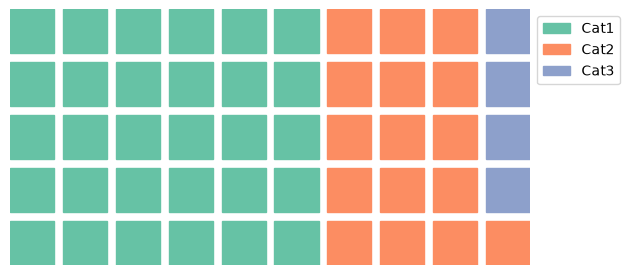

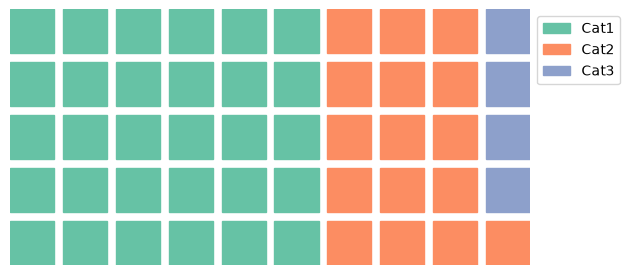

In [33]:
plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=10,
    values={'Cat1': 30, 'Cat2': 16, 'Cat3': 4},
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)}
)

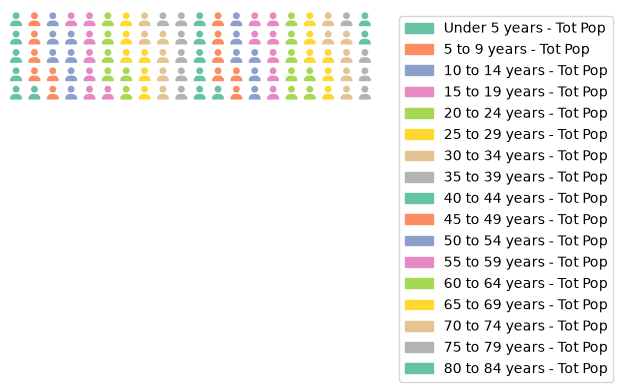

In [40]:
plt.figure(
  FigureClass=Waffle,
  rows=5,
  columns=20,
  values=df_cd_graph[ccn20_record['DC']],
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
  icons = 'user', 
  font_size = 10
)
plt.show()

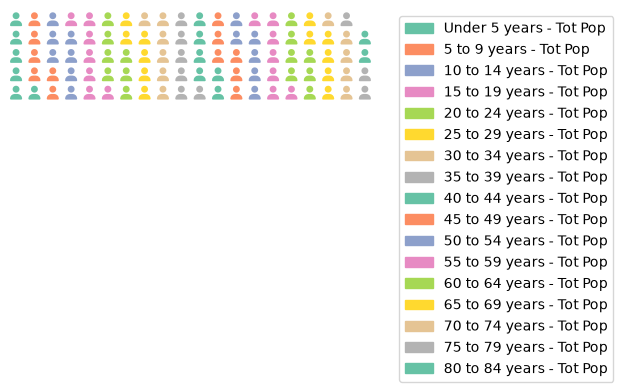

In [42]:
plt.figure(
  FigureClass=Waffle,
  rows=5,
  columns=20,
  values=df_state_graph[ccn20_record['State']],
  legend={'loc': 'upper left', 'bbox_to_anchor': (1.05, 1)},
  icons = 'user', 
  font_size = 10
)
plt.show()